In [1]:
# DOWNLOAD DATASET
import kagglehub
import shutil
import os

path = kagglehub.dataset_download("rm1000/brain-tumor-mri-scans")

DEST_DIR = "/content/dataset_brain_tumor"
shutil.copytree(path, DEST_DIR, dirs_exist_ok=True)

print("Dataset copied to", DEST_DIR)
print("Isi folder utama:", os.listdir(DEST_DIR))

Dataset copied to /content/dataset_brain_tumor
Isi folder utama: ['pituitary', 'glioma', 'meningioma', 'healthy']


In [2]:
# =========================
# STEP 1: IMPORT LIBRARY & KONFIGURASI UMUM
# =========================

# Import library dasar
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import library untuk split data, encoding label, dan evaluasi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Import TensorFlow dan Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121, ResNet50, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Mengatur seed agar hasil eksperimen lebih konsisten
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Konfigurasi ukuran gambar dan batch
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Jumlah epoch untuk model non-finetuning dan finetuning
EPOCHS_NON_FINETUNE = 25
EPOCHS_FINETUNE = 25

# Learning rate untuk model non-finetuning dan finetuning
LR_NON_FINETUNE = 1e-4
LR_FINETUNE = 1e-5

# AUTOTUNE digunakan agar pipeline TensorFlow lebih efisien
AUTOTUNE = tf.data.AUTOTUNE

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

2026-06-07 09:06:51.422382: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780823211.655691      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780823211.717644      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780823212.252478      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780823212.252523      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780823212.252526      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# Membaca Dataset

In [3]:
# =========================
# STEP 2: BACA DATASET & BUAT DATAFRAME
# =========================

image_paths = []
labels = []

# Ambil nama folder kelas
class_names = sorted([
    folder for folder in os.listdir(DEST_DIR)
    if os.path.isdir(os.path.join(DEST_DIR, folder))
])

print("Daftar kelas:", class_names)

# Ambil semua file gambar dari masing-masing folder kelas
for class_name in class_names:
    class_dir = os.path.join(DEST_DIR, class_name)

    for file_name in os.listdir(class_dir):
        file_path = os.path.join(class_dir, file_name)

        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(file_path)
            labels.append(class_name)

# Buat dataframe
df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print("Total gambar:", len(df))
print("\nJumlah gambar per kelas:")
print(df["label"].value_counts())

Daftar kelas: ['glioma', 'healthy', 'meningioma', 'pituitary']
Total gambar: 7023

Jumlah gambar per kelas:
label
healthy       2000
pituitary     1757
meningioma    1645
glioma        1621
Name: count, dtype: int64


# Encoding

In [4]:
# =========================
# STEP 3: ENCODING LABEL
# =========================

# Encode label teks menjadi angka
label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df["label"])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print("Mapping label:")
for idx, class_name in enumerate(class_names):
    print(f"{idx}: {class_name}")

print("\nJumlah kelas:", num_classes)

Mapping label:
0: glioma
1: healthy
2: meningioma
3: pituitary

Jumlah kelas: 4


# Data Splitting

In [5]:
# =========================
# STEP 4: SPLIT DATASET
# =========================
# Split pertama: train 70%, temp 30%
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label_encoded"]
)

# Split kedua: validation 15%, test 15%
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label_encoded"]
)

# Reset index
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Jumlah data:")
print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

print("\nDistribusi kelas train:")
print(train_df["label"].value_counts())

print("\nDistribusi kelas validation:")
print(val_df["label"].value_counts())

print("\nDistribusi kelas test:")
print(test_df["label"].value_counts())

Jumlah data:
Train      : 4916
Validation : 1053
Test       : 1054

Distribusi kelas train:
label
healthy       1400
pituitary     1230
meningioma    1151
glioma        1135
Name: count, dtype: int64

Distribusi kelas validation:
label
healthy       300
pituitary     263
meningioma    247
glioma        243
Name: count, dtype: int64

Distribusi kelas test:
label
healthy       300
pituitary     264
meningioma    247
glioma        243
Name: count, dtype: int64


# Preprocessing

In [6]:
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess_input

In [7]:
# =========================
# STEP 5: PREPROCESSING
# =========================

# Membuat augmentasi untuk data training
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05, seed=SEED),
    layers.RandomZoom(0.10, seed=SEED),
    layers.RandomTranslation(0.05, 0.05, seed=SEED),
], name="data_augmentation")


def load_image(image_path, label):
    # Membaca gambar dari path
    image = tf.io.read_file(image_path)

    # Decode gambar menjadi 3 channel
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Resize gambar ke ukuran 224x224
    image = tf.image.resize(image, IMG_SIZE)

    # Mengubah tipe data gambar dan label
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.int32)

    return image, label

# DenseNet121
def preprocess_densenet_train(image, label):
    # Augmentasi hanya untuk data training
    image = data_augmentation(image, training=True)
    # Preprocessing bawaan DenseNet121
    image = densenet_preprocess_input(image)
    return image, label

def preprocess_densenet_eval(image, label):
    # Preprocessing bawaan DenseNet121 tanpa augmentasi
    image = densenet_preprocess_input(image)
    return image, label

# ResNet50
def preprocess_resnet_train(image, label):
    # Augmentasi hanya untuk data training
    image = data_augmentation(image, training=True)
    # Preprocessing bawaan ResNet50
    image = resnet_preprocess_input(image)
    return image, label

def preprocess_resnet_eval(image, label):
    # Preprocessing bawaan ResNet50 tanpa augmentasi
    image = resnet_preprocess_input(image)
    return image, label

# EfficientNetB0
def preprocess_efficientnet_train(image, label):
    # Augmentasi hanya untuk data training
    image = data_augmentation(image, training=True)
    # Preprocessing bawaan EfficientNetB0
    image = efficientnet_preprocess_input(image)
    return image, label

def preprocess_efficientnet_eval(image, label):
    # Preprocessing bawaan EfficientNetB0 tanpa augmentasi
    image = efficientnet_preprocess_input(image)
    return image, label

print("Step 5 preprocessing berhasil dibuat.")

Step 5 preprocessing berhasil dibuat.


I0000 00:00:1780823225.808210      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780823225.814253      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# Dataset Pipeline

In [8]:
# =========================
# STEP 6: DATASET PIPELINE
# =========================

def create_base_dataset(dataframe, training=False):
    # Mengambil path gambar dan label dari dataframe
    image_paths = dataframe["image_path"].values
    labels = dataframe["label_encoded"].values

    # Membuat dataset dari path gambar dan label
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    # Membaca, decode, dan resize gambar
    dataset = dataset.map(load_image, num_parallel_calls=AUTOTUNE)

    # Mengacak data khusus training
    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    # Membuat batch data
    dataset = dataset.batch(BATCH_SIZE)

    return dataset


def create_densenet_dataset(dataframe, training=False):
    # Membuat dataset dasar
    dataset = create_base_dataset(dataframe, training=training)

    # Menerapkan preprocessing DenseNet121
    if training:
        dataset = dataset.map(preprocess_densenet_train, num_parallel_calls=AUTOTUNE)
    else:
        dataset = dataset.map(preprocess_densenet_eval, num_parallel_calls=AUTOTUNE)

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


def create_resnet_dataset(dataframe, training=False):
    # Membuat dataset dasar
    dataset = create_base_dataset(dataframe, training=training)

    # Menerapkan preprocessing ResNet50
    if training:
        dataset = dataset.map(preprocess_resnet_train, num_parallel_calls=AUTOTUNE)
    else:
        dataset = dataset.map(preprocess_resnet_eval, num_parallel_calls=AUTOTUNE)

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


def create_efficientnet_dataset(dataframe, training=False):
    # Membuat dataset dasar
    dataset = create_base_dataset(dataframe, training=training)

    # Menerapkan preprocessing EfficientNetB0
    if training:
        dataset = dataset.map(preprocess_efficientnet_train, num_parallel_calls=AUTOTUNE)
    else:
        dataset = dataset.map(preprocess_efficientnet_eval, num_parallel_calls=AUTOTUNE)

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

# Dataset khusus DenseNet121
densenet_train_ds = create_densenet_dataset(train_df, training=True)
densenet_val_ds = create_densenet_dataset(val_df, training=False)
densenet_test_ds = create_densenet_dataset(test_df, training=False)

# Dataset khusus ResNet50
resnet_train_ds = create_resnet_dataset(train_df, training=True)
resnet_val_ds = create_resnet_dataset(val_df, training=False)
resnet_test_ds = create_resnet_dataset(test_df, training=False)

# Dataset khusus EfficientNetB0
efficientnet_train_ds = create_efficientnet_dataset(train_df, training=True)
efficientnet_val_ds = create_efficientnet_dataset(val_df, training=False)
efficientnet_test_ds = create_efficientnet_dataset(test_df, training=False)

print("Step 6 dataset pipeline berhasil dibuat.")
print("DenseNet Train batches     :", len(densenet_train_ds))
print("DenseNet Validation batches:", len(densenet_val_ds))
print("DenseNet Test batches      :", len(densenet_test_ds))
print("ResNet Train batches       :", len(resnet_train_ds))
print("ResNet Validation batches  :", len(resnet_val_ds))
print("ResNet Test batches        :", len(resnet_test_ds))
print("EfficientNet Train batches      :", len(efficientnet_train_ds))
print("EfficientNet Validation batches :", len(efficientnet_val_ds))
print("EfficientNet Test batches       :", len(efficientnet_test_ds))

Step 6 dataset pipeline berhasil dibuat.
DenseNet Train batches     : 154
DenseNet Validation batches: 33
DenseNet Test batches      : 33
ResNet Train batches       : 154
ResNet Validation batches  : 33
ResNet Test batches        : 33
EfficientNet Train batches      : 154
EfficientNet Validation batches : 33
EfficientNet Test batches       : 33


# Build Model

In [9]:
# =========================
# STEP 7: FUNGSI BUILD MODEL
# =========================

# Fungsi ini dipakai bersama oleh DenseNet121 dan ResNet50
# untuk menambahkan classifier di bagian akhir model.

def add_classifier_head(base_model, model_name):
    # Membuat input sesuai ukuran gambar
    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    # Memasukkan input ke backbone model
    x = base_model(inputs, training=False)

    # Mengambil fitur utama dari backbone
    x = layers.GlobalAveragePooling2D()(x)

    # Menambahkan dropout untuk mengurangi overfitting
    x = layers.Dropout(0.3)(x)

    # Menambahkan dense layer sebagai classifier tambahan
    x = layers.Dense(256, activation="relu")(x)

    # Menambahkan dropout kedua
    x = layers.Dropout(0.3)(x)

    # Output layer sesuai jumlah kelas
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    # Membuat model akhir
    model = models.Model(inputs, outputs, name=model_name)

    return model


# =========================
# DENSENET121
# =========================

def build_densenet121(fine_tuning=False, unfreeze_layers=30):
    try:
        # Menggunakan DenseNet121 sebagai backbone
        base_model = DenseNet121(
            weights="imagenet",
            include_top=False,
            input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
        )

        # DenseNet121 non-finetuning: seluruh backbone dibekukan
        if not fine_tuning:
            base_model.trainable = False
            model_name = "DenseNet121_Non_Finetuning"
            learning_rate = LR_NON_FINETUNE

        # DenseNet121 finetuning: sebagian layer akhir dibuka
        else:
            base_model.trainable = True

            for layer in base_model.layers[:-unfreeze_layers]:
                layer.trainable = False

            model_name = "DenseNet121_Finetuning"
            learning_rate = LR_FINETUNE

        # Menambahkan classifier head
        model = add_classifier_head(base_model, model_name)

        # Compile model DenseNet121
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        print(f"{model_name} berhasil dibuat dan dicompile.")
        return model

    except Exception as e:
        print("DenseNet121 gagal dibuat.")
        print("Error:", e)
        return None


# =========================
# RESNET50
# =========================

def build_resnet50(fine_tuning=False, unfreeze_layers=30):
    try:
        # Menggunakan ResNet50 sebagai backbone
        base_model = ResNet50(
            weights="imagenet",
            include_top=False,
            input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
        )

        # ResNet50 non-finetuning: seluruh backbone dibekukan
        if not fine_tuning:
            base_model.trainable = False
            model_name = "ResNet50_Non_Finetuning"
            learning_rate = LR_NON_FINETUNE

        # ResNet50 finetuning: sebagian layer akhir dibuka
        else:
            base_model.trainable = True

            for layer in base_model.layers[:-unfreeze_layers]:
                layer.trainable = False

            model_name = "ResNet50_Finetuning"
            learning_rate = LR_FINETUNE

        # Menambahkan classifier head
        model = add_classifier_head(base_model, model_name)

        # Compile model ResNet50
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        print(f"{model_name} berhasil dibuat dan dicompile.")
        return model

    except Exception as e:
        print("ResNet50 gagal dibuat.")
        print("Error:", e)
        return None

# =========================
# EFFICIENTNETB0
# =========================

def build_efficientnetb0(fine_tuning=False, unfreeze_layers=30):
    try:
        # Menggunakan EfficientNetB0 sebagai backbone
        base_model = EfficientNetB0(
            weights="imagenet",
            include_top=False,
            input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
        )

        # EfficientNetB0 non-finetuning: seluruh backbone dibekukan
        if not fine_tuning:
            base_model.trainable = False
            model_name = "EfficientNetB0_Non_Finetuning"
            learning_rate = LR_NON_FINETUNE

        # EfficientNetB0 finetuning: sebagian layer akhir dibuka
        else:
            base_model.trainable = True

            for layer in base_model.layers[:-unfreeze_layers]:
                layer.trainable = False

            model_name = "EfficientNetB0_Finetuning"
            learning_rate = LR_FINETUNE

        # Menambahkan classifier head
        model = add_classifier_head(base_model, model_name)

        # Compile model EfficientNetB0
        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=learning_rate
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        print(f"{model_name} berhasil dibuat dan dicompile.")
        return model

    except Exception as e:
        print("EfficientNetB0 gagal dibuat.")
        print("Error:", e)
        return None

In [10]:
# =========================
# STEP 8: MEMBANGUN 6 MODEL
# =========================

# Membuat model DenseNet121 non-finetuning
densenet_non_ft = build_densenet121(fine_tuning=False)

# Membuat model DenseNet121 finetuning
densenet_ft = build_densenet121(fine_tuning=True, unfreeze_layers=30)

# Membuat model ResNet50 non-finetuning
resnet_non_ft = build_resnet50(fine_tuning=False)

# Membuat model ResNet50 finetuning
resnet_ft = build_resnet50(fine_tuning=True, unfreeze_layers=30)

# Membuat model EfficientNetB0 non-finetuning
efficientnet_non_ft = build_efficientnetb0(fine_tuning=False)

# Membuat model EfficientNetB0 finetuning
efficientnet_ft = build_efficientnetb0(fine_tuning=True, unfreeze_layers=30)

# Mengecek apakah semua model berhasil dibuat
models_dict = {
    "DenseNet121 Non-Finetuning": densenet_non_ft,
    "DenseNet121 Finetuning": densenet_ft,
    "ResNet50 Non-Finetuning": resnet_non_ft,
    "ResNet50 Finetuning": resnet_ft,
    "EfficientNetB0 Non-Finetuning": efficientnet_non_ft,
    "EfficientNetB0 Finetuning": efficientnet_ft
}

print("\nStatus model:")
for name, model in models_dict.items():
    if model is not None:
        print(f"{name}: berhasil dibuat")
    else:
        print(f"{name}: gagal dibuat")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
DenseNet121_Non_Finetuning berhasil dibuat dan dicompile.
DenseNet121_Finetuning berhasil dibuat dan dicompile.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50_Non_Finetuning berhasil dibuat dan dicompile.
ResNet50_Finetuning berhasil dibuat dan dicompile.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0_Non_Finetuning berhasil dibuat dan dicompile.
EfficientNetB0_Finetuning berhasil dibuat dan dicompile.

Status model:
DenseNet121 Non-Finetuning: berhasil dibuat
DenseNet121 Finetuning: berhasil dibuat
ResNet50 Non-Finetuning: berhasil dibuat
ResNet50 Finetuning: berhasil dibuat
EfficientNetB0 Non-Finetuning: berhasil dibuat
EfficientNetB0 Finetuning: berhasil dibuat


# Training Model

In [11]:
# =========================
# STEP 9: FUNGSI TRAINING DAN EVALUASI
# =========================

def plot_training_history(history, model_label):
    # Mengambil nilai accuracy dan loss dari history training
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(1, len(acc) + 1)

    # Menampilkan grafik accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.title(f"Accuracy - {model_label}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Menampilkan grafik loss
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.title(f"Loss - {model_label}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


def evaluate_model(model, model_label, test_data):
    # Mengevaluasi model menggunakan test data sesuai preprocessing model
    test_loss, test_accuracy = model.evaluate(test_data, verbose=1)

    print(f"\nHasil Evaluasi {model_label}")
    print(f"Test Loss     : {test_loss:.4f}")
    print(f"Test Accuracy : {test_accuracy:.4f}")

    # Mengambil label asli dan hasil prediksi dari test data
    y_true = []
    y_pred = []

    for images, labels in test_data:
        predictions = model.predict(images, verbose=0)
        predicted_labels = np.argmax(predictions, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted_labels)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Menampilkan classification report
    print("\nClassification Report:")
    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True
    )

    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names
    ))

    # Menampilkan confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"Confusion Matrix - {model_label}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    # Menyimpan hasil evaluasi dalam dictionary
    result = {
        "Model": model_label,
        "Test Loss": test_loss,
        "Test Accuracy": test_accuracy,
        "Macro F1-Score": report["macro avg"]["f1-score"],
        "Weighted F1-Score": report["weighted avg"]["f1-score"]
    }

    return result


def run_experiment(model, model_label, train_data, val_data, test_data, epochs):
    # Callback untuk menghentikan training jika validation loss tidak membaik
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    # Callback untuk menurunkan learning rate jika validation loss stagnan
    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    )

    print(f"\nMulai eksperimen: {model_label}")

    # Melakukan training model dengan dataset sesuai arsitektur
    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=epochs,
        callbacks=[early_stopping, reduce_lr]
    )

    print(f"\nTraining selesai: {model_label}")

    # Menampilkan grafik training
    plot_training_history(history, model_label)

    # Melakukan evaluasi model dengan test data sesuai arsitektur
    result = evaluate_model(
        model=model,
        model_label=model_label,
        test_data=test_data
    )

    print(f"\nEksperimen selesai: {model_label}")

    return history, result

# Eksperimen

In [15]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
tf.get_logger().setLevel('ERROR')


Mulai eksperimen: DenseNet121 Non-Finetuning
Epoch 1/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 32s 178ms/step - accuracy: 0.7203 - loss: 0.7077 - val_accuracy: 0.7996 - val_loss: 0.5321 - learning_rate: 1.0000e-04
Epoch 2/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 32s 177ms/step - accuracy: 0.7651 - loss: 0.6095 - val_accuracy: 0.7873 - val_loss: 0.5501 - learning_rate: 1.0000e-04
Epoch 3/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 32s 179ms/step - accuracy: 0.7771 - loss: 0.5684 - val_accuracy: 0.7949 - val_loss: 0.5199 - learning_rate: 1.0000e-04
Epoch 4/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 32s 177ms/step - accuracy: 0.7939 - loss: 0.5174 - val_accuracy: 0.8186 - val_loss: 0.4673 - learning_rate: 1.0000e-04
Epoch 5/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 32s 181ms/step - accuracy: 0.8027 - loss: 0.5030 - val_accuracy: 0.8215 - val_loss: 0.4491 - learning_rate: 1.0000e-04
Epoch 6/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 32s 180ms/step - accuracy: 0.8110 - loss: 0.4797 - val_accuracy: 0.8405 - val_loss: 0.4212 - learning_rate: 1.0000e-04


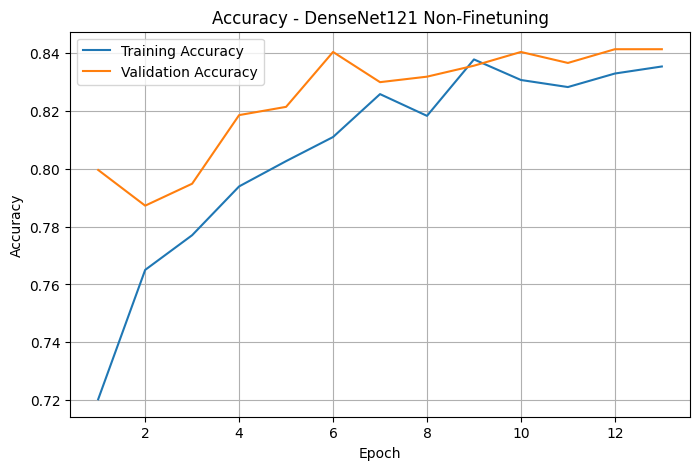

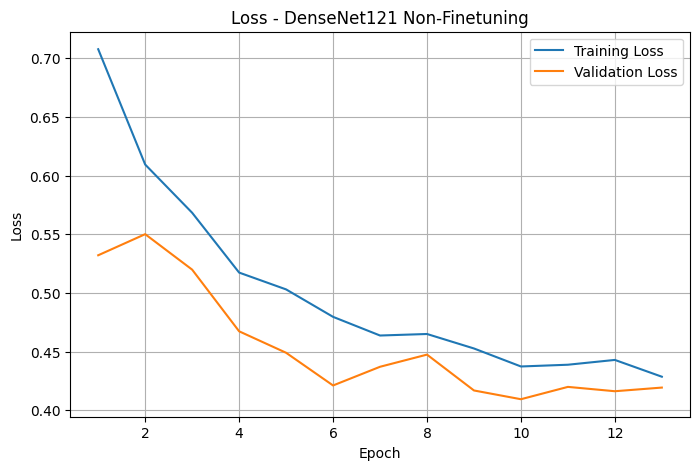

33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 453ms/step - accuracy: 0.8558 - loss: 0.4145

Hasil Evaluasi DenseNet121 Non-Finetuning
Test Loss     : 0.4145
Test Accuracy : 0.8558

Classification Report:
              precision    recall  f1-score   support

      glioma       0.90      0.86      0.88       243
     healthy       0.94      0.93      0.93       300
  meningioma       0.84      0.62      0.71       247
   pituitary       0.76      1.00      0.86       264

    accuracy                           0.86      1054
   macro avg       0.86      0.85      0.85      1054
weighted avg       0.86      0.86      0.85      1054



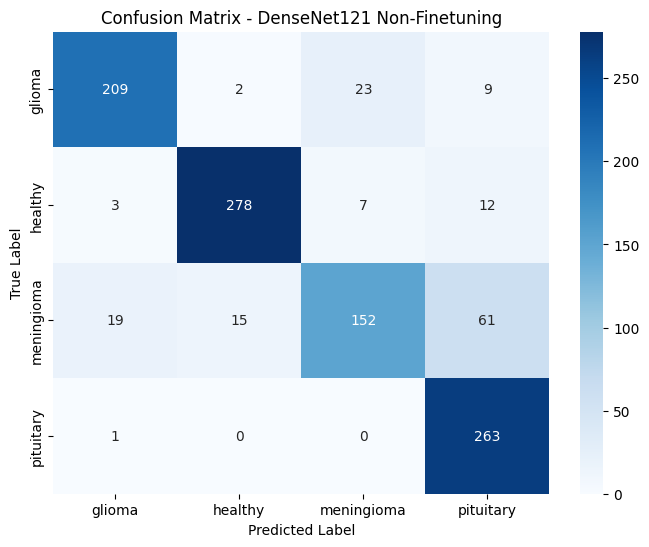


Eksperimen selesai: DenseNet121 Non-Finetuning

Hasil sementara:


,Model,Test Loss,Test Accuracy,Macro F1-Score,Weighted F1-Score
0,DenseNet121 Non-Finetuning,0.414508,0.855787,0.846697,0.851258


In [16]:
# =========================
# STEP 10: EKSPERIMEN DENSENET121 NON-FINETUNING
# =========================

summary_results = []

densenet_non_ft_history, densenet_non_ft_result = run_experiment(
    model=densenet_non_ft,
    model_label="DenseNet121 Non-Finetuning",
    train_data=densenet_train_ds,
    val_data=densenet_val_ds,
    test_data=densenet_test_ds,
    epochs=EPOCHS_NON_FINETUNE
)

summary_results.append(densenet_non_ft_result)

print("\nHasil sementara:")
pd.DataFrame(summary_results)


Mulai eksperimen: DenseNet121 Finetuning
Epoch 1/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 95s 394ms/step - accuracy: 0.2986 - loss: 1.6563 - val_accuracy: 0.5252 - val_loss: 1.1376 - learning_rate: 1.0000e-05
Epoch 2/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 32s 179ms/step - accuracy: 0.4862 - loss: 1.2164 - val_accuracy: 0.7123 - val_loss: 0.8446 - learning_rate: 1.0000e-05
Epoch 3/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 31s 178ms/step - accuracy: 0.6060 - loss: 0.9842 - val_accuracy: 0.7654 - val_loss: 0.6939 - learning_rate: 1.0000e-05
Epoch 4/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 32s 179ms/step - accuracy: 0.6611 - loss: 0.8543 - val_accuracy: 0.7863 - val_loss: 0.6095 - learning_rate: 1.0000e-05
Epoch 5/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 31s 177ms/step - accuracy: 0.7006 - loss: 0.7796 - val_accuracy: 0.8139 - val_loss: 0.5373 - learning_rate: 1.0000e-05
Epoch 6/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 31s 177ms/step - accuracy: 0.7366 - loss: 0.6795 - val_accuracy: 0.8196 - val_loss: 0.4953 - learning_rate: 1.0000e-05
Epoc

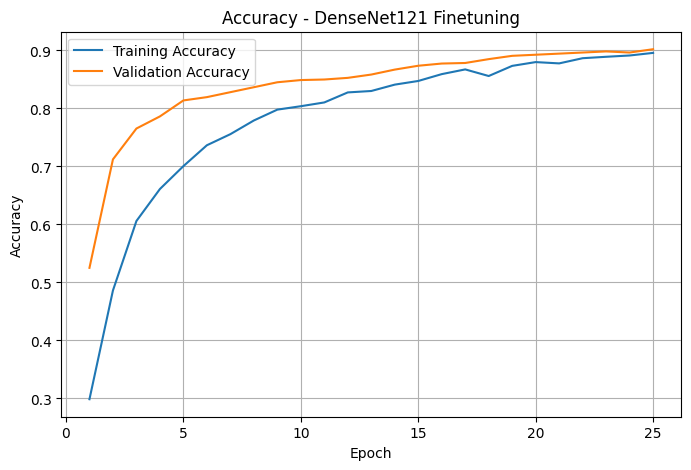

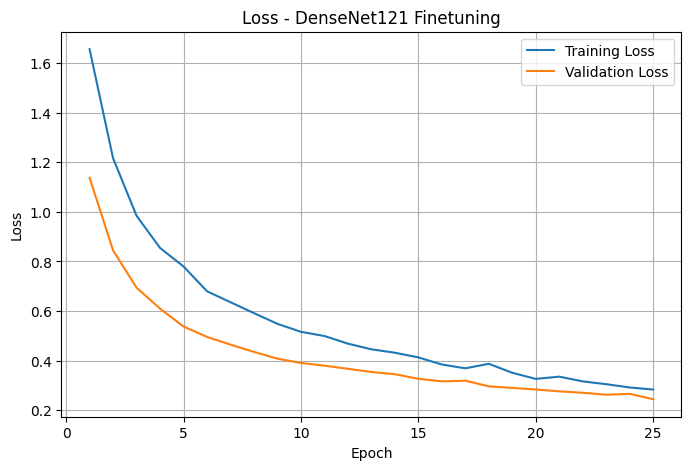

33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 315ms/step - accuracy: 0.9051 - loss: 0.2646

Hasil Evaluasi DenseNet121 Finetuning
Test Loss     : 0.2646
Test Accuracy : 0.9051

Classification Report:
              precision    recall  f1-score   support

      glioma       0.94      0.88      0.91       243
     healthy       0.97      0.95      0.96       300
  meningioma       0.87      0.77      0.82       247
   pituitary       0.84      1.00      0.91       264

    accuracy                           0.91      1054
   macro avg       0.91      0.90      0.90      1054
weighted avg       0.91      0.91      0.90      1054



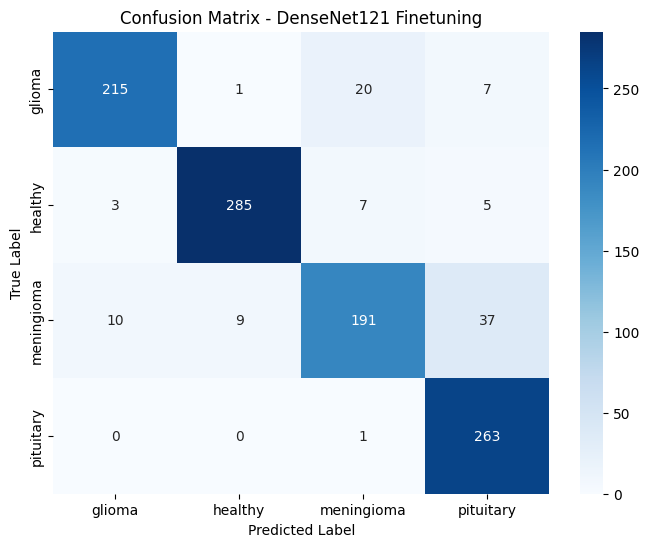


Eksperimen selesai: DenseNet121 Finetuning

Hasil sementara:


,Model,Test Loss,Test Accuracy,Macro F1-Score,Weighted F1-Score
0,DenseNet121 Non-Finetuning,0.414508,0.855787,0.846697,0.851258
1,DenseNet121 Finetuning,0.264622,0.905123,0.900968,0.903987


In [17]:
# =========================
# STEP 10B: EKSPERIMEN DENSENET121 FINETUNING
# =========================

densenet_ft_history, densenet_ft_result = run_experiment(
    model=densenet_ft,
    model_label="DenseNet121 Finetuning",
    train_data=densenet_train_ds,
    val_data=densenet_val_ds,
    test_data=densenet_test_ds,
    epochs=EPOCHS_FINETUNE
)

summary_results.append(densenet_ft_result)

print("\nHasil sementara:")
pd.DataFrame(summary_results)


Mulai eksperimen: ResNet50 Non-Finetuning
Epoch 1/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 60s 278ms/step - accuracy: 0.6330 - loss: 0.9092 - val_accuracy: 0.8101 - val_loss: 0.4916 - learning_rate: 1.0000e-04
Epoch 2/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 33s 183ms/step - accuracy: 0.8011 - loss: 0.5247 - val_accuracy: 0.8338 - val_loss: 0.3963 - learning_rate: 1.0000e-04
Epoch 3/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 33s 185ms/step - accuracy: 0.8354 - loss: 0.4320 - val_accuracy: 0.8661 - val_loss: 0.3400 - learning_rate: 1.0000e-04
Epoch 4/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 32s 182ms/step - accuracy: 0.8509 - loss: 0.3923 - val_accuracy: 0.8689 - val_loss: 0.3240 - learning_rate: 1.0000e-04
Epoch 5/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 33s 187ms/step - accuracy: 0.8643 - loss: 0.3678 - val_accuracy: 0.8481 - val_loss: 0.3596 - learning_rate: 1.0000e-04
Epoch 6/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 32s 182ms/step - accuracy: 0.8723 - loss: 0.3432 - val_accuracy: 0.8908 - val_loss: 0.2890 - learning_rate: 1.0000e-04
Epo

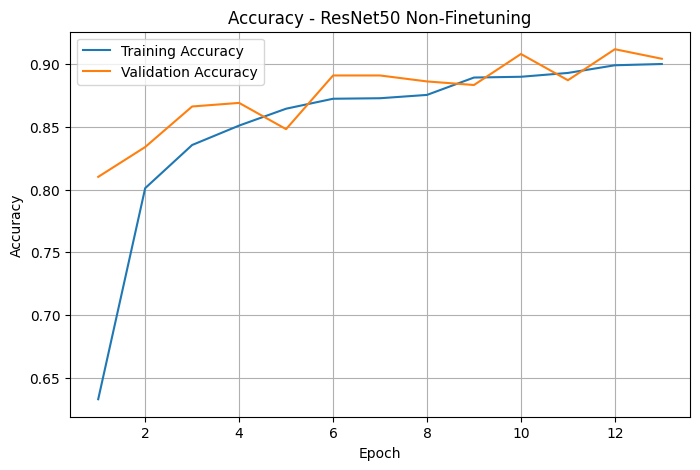

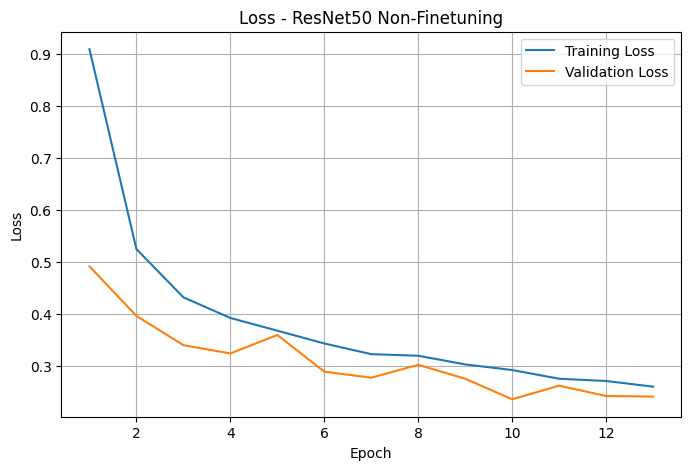

33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 238ms/step - accuracy: 0.9051 - loss: 0.2588

Hasil Evaluasi ResNet50 Non-Finetuning
Test Loss     : 0.2588
Test Accuracy : 0.9051

Classification Report:
              precision    recall  f1-score   support

      glioma       0.93      0.88      0.91       243
     healthy       0.97      0.95      0.96       300
  meningioma       0.84      0.79      0.81       247
   pituitary       0.88      0.98      0.93       264

    accuracy                           0.91      1054
   macro avg       0.90      0.90      0.90      1054
weighted avg       0.91      0.91      0.90      1054



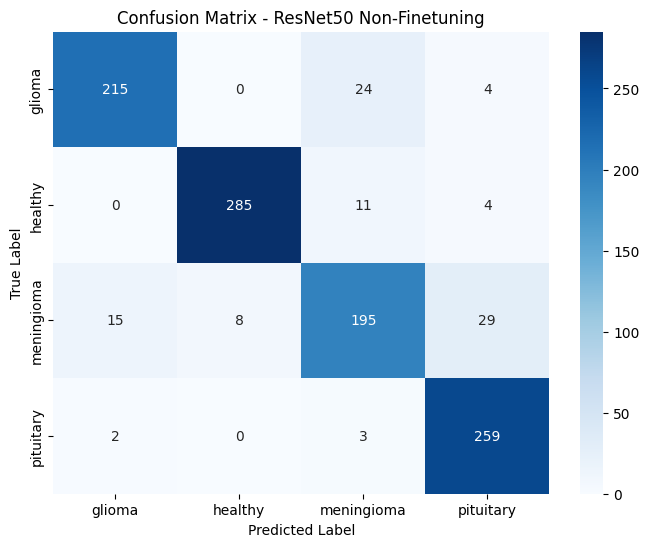


Eksperimen selesai: ResNet50 Non-Finetuning

Hasil sementara:


,Model,Test Loss,Test Accuracy,Macro F1-Score,Weighted F1-Score
0,DenseNet121 Non-Finetuning,0.414508,0.855787,0.846697,0.851258
1,DenseNet121 Finetuning,0.264622,0.905123,0.900968,0.903987
2,ResNet50 Non-Finetuning,0.258786,0.905123,0.900994,0.904393


In [18]:
# =========================
# STEP 10C: EKSPERIMEN RESNET50 NON-FINETUNING
# =========================

resnet_non_ft_history, resnet_non_ft_result = run_experiment(
    model=resnet_non_ft,
    model_label="ResNet50 Non-Finetuning",
    train_data=resnet_train_ds,
    val_data=resnet_val_ds,
    test_data=resnet_test_ds,
    epochs=EPOCHS_NON_FINETUNE
)

summary_results.append(resnet_non_ft_result)

print("\nHasil sementara:")
pd.DataFrame(summary_results)


Mulai eksperimen: ResNet50 Finetuning
Epoch 1/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 66s 274ms/step - accuracy: 0.6015 - loss: 0.9867 - val_accuracy: 0.8376 - val_loss: 0.4439 - learning_rate: 1.0000e-05
Epoch 2/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 34s 189ms/step - accuracy: 0.8295 - loss: 0.4799 - val_accuracy: 0.8908 - val_loss: 0.2911 - learning_rate: 1.0000e-05
Epoch 3/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 33s 188ms/step - accuracy: 0.8784 - loss: 0.3429 - val_accuracy: 0.9098 - val_loss: 0.2339 - learning_rate: 1.0000e-05
Epoch 4/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 33s 190ms/step - accuracy: 0.9028 - loss: 0.2687 - val_accuracy: 0.9259 - val_loss: 0.1952 - learning_rate: 1.0000e-05
Epoch 5/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 33s 189ms/step - accuracy: 0.9272 - loss: 0.2090 - val_accuracy: 0.9440 - val_loss: 0.1658 - learning_rate: 1.0000e-05
Epoch 6/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 33s 188ms/step - accuracy: 0.9331 - loss: 0.1856 - val_accuracy: 0.9478 - val_loss: 0.1462 - learning_rate: 1.0000e-05
Epoch 7

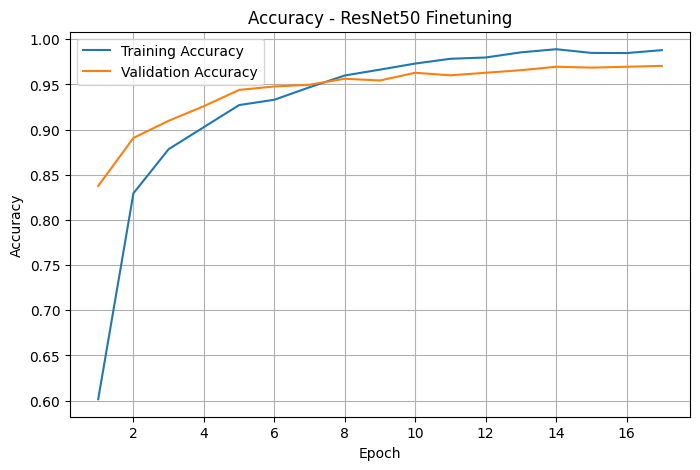

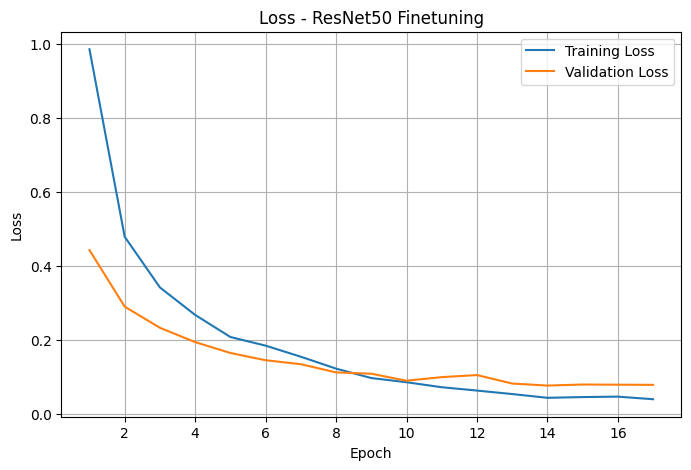

33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - accuracy: 0.9687 - loss: 0.1000

Hasil Evaluasi ResNet50 Finetuning
Test Loss     : 0.1000
Test Accuracy : 0.9687

Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.95      0.97       243
     healthy       1.00      0.98      0.99       300
  meningioma       0.95      0.94      0.94       247
   pituitary       0.94      1.00      0.97       264

    accuracy                           0.97      1054
   macro avg       0.97      0.97      0.97      1054
weighted avg       0.97      0.97      0.97      1054



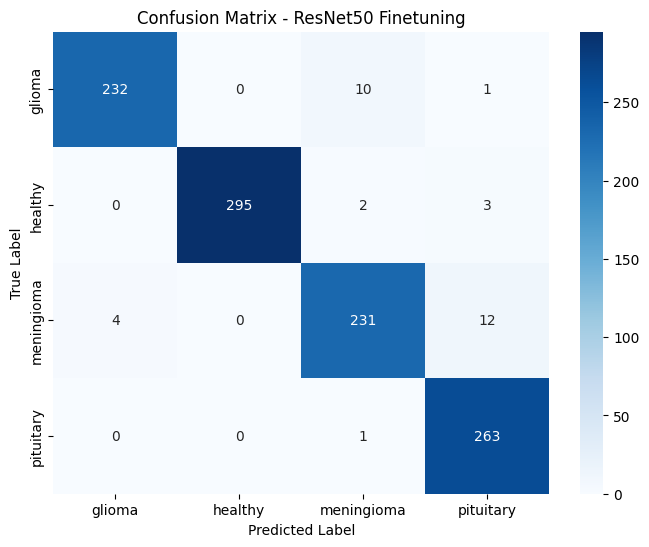


Eksperimen selesai: ResNet50 Finetuning

Hasil sementara:


,Model,Test Loss,Test Accuracy,Macro F1-Score,Weighted F1-Score
0,DenseNet121 Non-Finetuning,0.414508,0.855787,0.846697,0.851258
1,DenseNet121 Finetuning,0.264622,0.905123,0.900968,0.903987
2,ResNet50 Non-Finetuning,0.258786,0.905123,0.900994,0.904393
3,ResNet50 Finetuning,0.099962,0.968691,0.967478,0.968706


In [19]:
# =========================
# STEP 10D: EKSPERIMEN RESNET50 FINETUNING
# =========================

resnet_ft_history, resnet_ft_result = run_experiment(
    model=resnet_ft,
    model_label="ResNet50 Finetuning",
    train_data=resnet_train_ds,
    val_data=resnet_val_ds,
    test_data=resnet_test_ds,
    epochs=EPOCHS_FINETUNE
)

summary_results.append(resnet_ft_result)

print("\nHasil sementara:")
pd.DataFrame(summary_results)


Mulai eksperimen: EfficientNetB0 Non-Finetuning
Epoch 1/25


2026-06-07 09:50:07.740409: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 09:50:07.884326: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 09:50:08.229086: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 09:50:08.370634: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 09:50:09.154903: E external/local_xla/xla/stream_

152/154 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.4888 - loss: 1.1668

2026-06-07 09:50:44.750623: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 09:50:44.891782: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 09:50:45.216802: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 09:50:45.357837: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 09:50:46.158827: E external/local_xla/xla/stream_

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.4906 - loss: 1.1636

2026-06-07 09:51:06.054075: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 09:51:06.197238: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 09:51:06.535889: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 09:51:06.677895: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 09:51:07.454239: E external/local_xla/xla/stream_

154/154 ━━━━━━━━━━━━━━━━━━━━ 86s 359ms/step - accuracy: 0.6286 - loss: 0.9192 - val_accuracy: 0.6914 - val_loss: 0.7024 - learning_rate: 1.0000e-04
Epoch 2/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 27s 149ms/step - accuracy: 0.7797 - loss: 0.5824 - val_accuracy: 0.7227 - val_loss: 0.6670 - learning_rate: 1.0000e-04
Epoch 3/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 27s 149ms/step - accuracy: 0.8076 - loss: 0.5028 - val_accuracy: 0.7616 - val_loss: 0.6044 - learning_rate: 1.0000e-04
Epoch 4/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 27s 152ms/step - accuracy: 0.8358 - loss: 0.4548 - val_accuracy: 0.7759 - val_loss: 0.5925 - learning_rate: 1.0000e-04
Epoch 5/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 27s 148ms/step - accuracy: 0.8387 - loss: 0.4311 - val_accuracy: 0.7664 - val_loss: 0.6119 - learning_rate: 1.0000e-04
Epoch 6/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 27s 147ms/step - accuracy: 0.8432 - loss: 0.4058 - val_accuracy: 0.7901 - val_loss: 0.5639 - learning_rate: 1.0000e-04
Epoch 7/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 27s 149ms/step - 

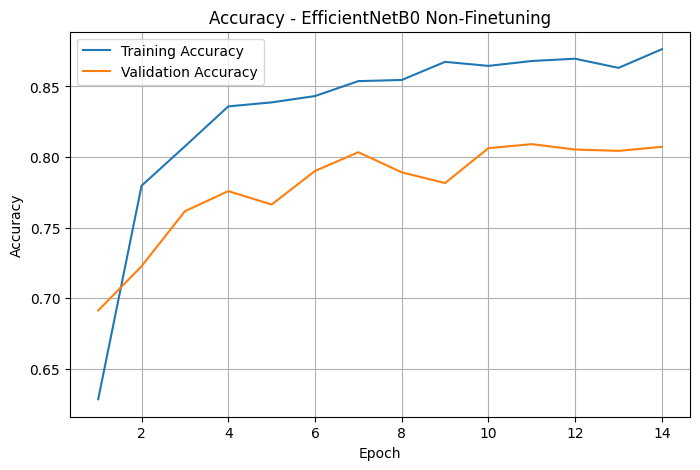

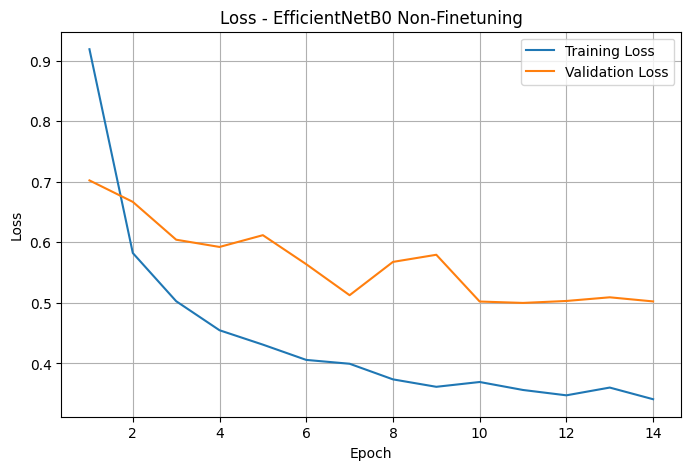

31/33 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7793 - loss: 0.5821

2026-06-07 09:57:05.797634: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 09:57:05.940856: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 09:57:06.281726: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 09:57:06.422925: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 09:57:07.189540: E external/local_xla/xla/stream_

33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 352ms/step - accuracy: 0.7913 - loss: 0.5544

Hasil Evaluasi EfficientNetB0 Non-Finetuning
Test Loss     : 0.5544
Test Accuracy : 0.7913

Classification Report:
              precision    recall  f1-score   support

      glioma       0.93      0.65      0.77       243
     healthy       0.96      0.90      0.93       300
  meningioma       0.74      0.57      0.65       247
   pituitary       0.64      1.00      0.78       264

    accuracy                           0.79      1054
   macro avg       0.82      0.78      0.78      1054
weighted avg       0.82      0.79      0.79      1054



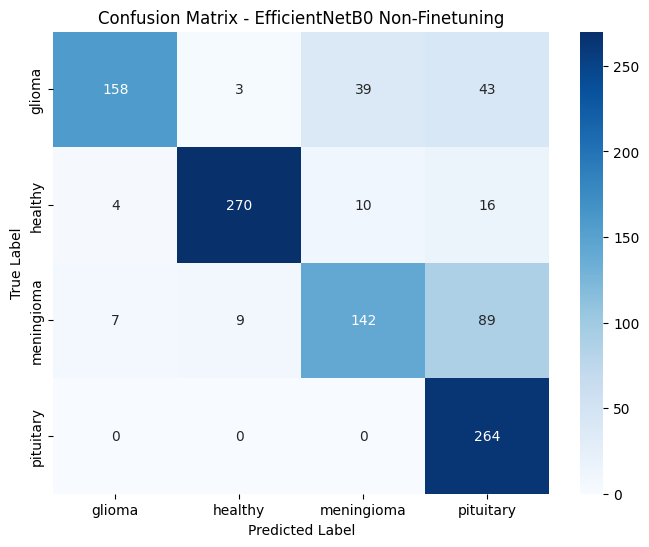


Eksperimen selesai: EfficientNetB0 Non-Finetuning

Hasil sementara:


,Model,Test Loss,Test Accuracy,Macro F1-Score,Weighted F1-Score
0,DenseNet121 Non-Finetuning,0.414508,0.855787,0.846697,0.851258
1,DenseNet121 Finetuning,0.264622,0.905123,0.900968,0.903987
2,ResNet50 Non-Finetuning,0.258786,0.905123,0.900994,0.904393
3,ResNet50 Finetuning,0.099962,0.968691,0.967478,0.968706
4,EfficientNetB0 Non-Finetuning,0.554431,0.791271,0.781073,0.788506


In [20]:
# =========================
# STEP 10E: EKSPERIMEN EFFICIENTNETB0 NON-FINETUNING
# =========================

efficientnet_non_ft_history, efficientnet_non_ft_result = run_experiment(
    model=efficientnet_non_ft,
    model_label="EfficientNetB0 Non-Finetuning",
    train_data=efficientnet_train_ds,
    val_data=efficientnet_val_ds,
    test_data=efficientnet_test_ds,
    epochs=EPOCHS_NON_FINETUNE
)

summary_results.append(efficientnet_non_ft_result)

print("\nHasil sementara:")
pd.DataFrame(summary_results)


Mulai eksperimen: EfficientNetB0 Finetuning
Epoch 1/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 77s 302ms/step - accuracy: 0.4231 - loss: 1.2665 - val_accuracy: 0.6838 - val_loss: 1.0170 - learning_rate: 1.0000e-05
Epoch 2/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 28s 151ms/step - accuracy: 0.6469 - loss: 0.9763 - val_accuracy: 0.7255 - val_loss: 0.8017 - learning_rate: 1.0000e-05
Epoch 3/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 27s 150ms/step - accuracy: 0.7333 - loss: 0.8029 - val_accuracy: 0.7607 - val_loss: 0.6818 - learning_rate: 1.0000e-05
Epoch 4/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 27s 149ms/step - accuracy: 0.7640 - loss: 0.6816 - val_accuracy: 0.7825 - val_loss: 0.6061 - learning_rate: 1.0000e-05
Epoch 5/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 27s 152ms/step - accuracy: 0.7878 - loss: 0.6119 - val_accuracy: 0.8006 - val_loss: 0.5466 - learning_rate: 1.0000e-05
Epoch 6/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 27s 151ms/step - accuracy: 0.8031 - loss: 0.5489 - val_accuracy: 0.8139 - val_loss: 0.5072 - learning_rate: 1.0000e-05
E

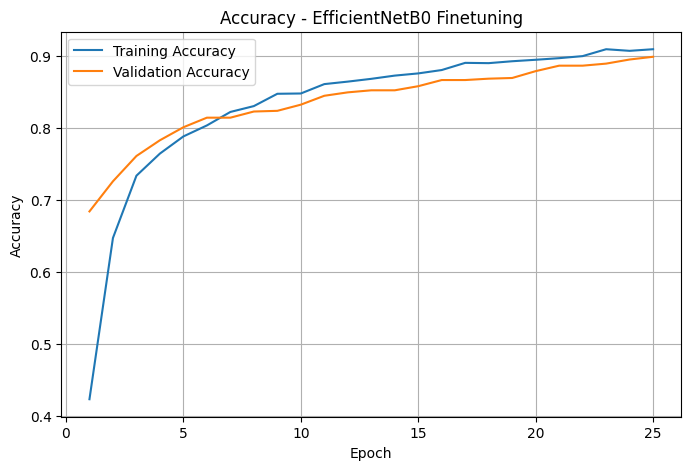

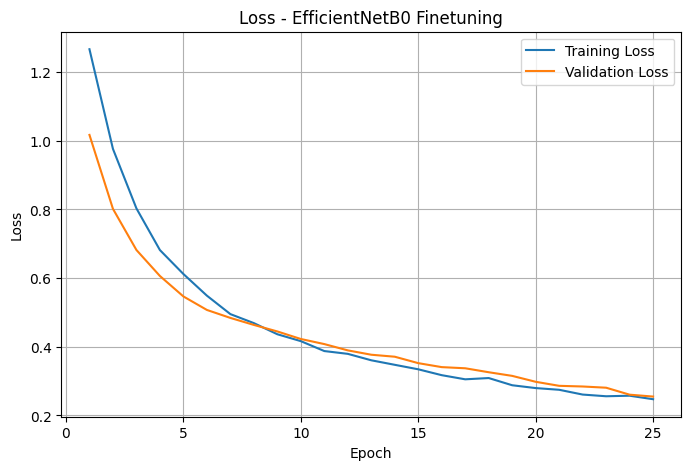

33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - accuracy: 0.9013 - loss: 0.2746

Hasil Evaluasi EfficientNetB0 Finetuning
Test Loss     : 0.2746
Test Accuracy : 0.9013

Classification Report:
              precision    recall  f1-score   support

      glioma       0.96      0.86      0.91       243
     healthy       0.98      0.94      0.96       300
  meningioma       0.84      0.79      0.82       247
   pituitary       0.83      1.00      0.91       264

    accuracy                           0.90      1054
   macro avg       0.90      0.90      0.90      1054
weighted avg       0.91      0.90      0.90      1054



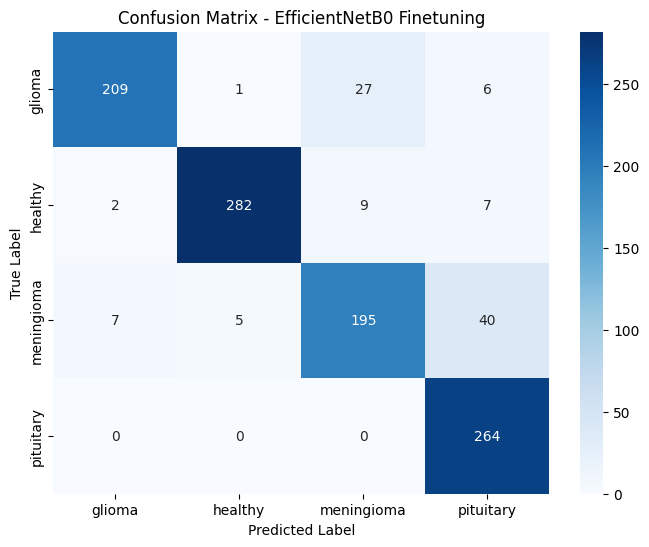


Eksperimen selesai: EfficientNetB0 Finetuning

Hasil sementara:


,Model,Test Loss,Test Accuracy,Macro F1-Score,Weighted F1-Score
0,DenseNet121 Non-Finetuning,0.414508,0.855787,0.846697,0.851258
1,DenseNet121 Finetuning,0.264622,0.905123,0.900968,0.903987
2,ResNet50 Non-Finetuning,0.258786,0.905123,0.900994,0.904393
3,ResNet50 Finetuning,0.099962,0.968691,0.967478,0.968706
4,EfficientNetB0 Non-Finetuning,0.554431,0.791271,0.781073,0.788506
5,EfficientNetB0 Finetuning,0.274573,0.901328,0.897646,0.900886


In [21]:
# =========================
# STEP 10F: EKSPERIMEN EFFICIENTNETB0 FINETUNING
# =========================

efficientnet_ft_history, efficientnet_ft_result = run_experiment(
    model=efficientnet_ft,
    model_label="EfficientNetB0 Finetuning",
    train_data=efficientnet_train_ds,
    val_data=efficientnet_val_ds,
    test_data=efficientnet_test_ds,
    epochs=EPOCHS_FINETUNE
)

summary_results.append(efficientnet_ft_result)

print("\nHasil sementara:")
pd.DataFrame(summary_results)

In [30]:
# =========================
# STEP 11: REKAP HASIL MODEL
# =========================

results_df = pd.DataFrame(summary_results)

results_df

,Model,Test Loss,Test Accuracy,Macro F1-Score,Weighted F1-Score
0,DenseNet121 Non-Finetuning,0.414508,0.855787,0.846697,0.851258
1,DenseNet121 Finetuning,0.264622,0.905123,0.900968,0.903987
2,ResNet50 Non-Finetuning,0.258786,0.905123,0.900994,0.904393
3,ResNet50 Finetuning,0.099962,0.968691,0.967478,0.968706
4,EfficientNetB0 Non-Finetuning,0.554431,0.791271,0.781073,0.788506
5,EfficientNetB0 Finetuning,0.274573,0.901328,0.897646,0.900886


In [27]:
# =========================
# STEP 12: PILIH MODEL TERBAIK
# =========================

best_row = results_df.loc[results_df["Test Accuracy"].idxmax()]

print("Model Terbaik:")
print(best_row)

model_mapping = {
    "DenseNet121 Non-Finetuning": densenet_non_ft,
    "DenseNet121 Finetuning": densenet_ft,
    "ResNet50 Non-Finetuning": resnet_non_ft,
    "ResNet50 Finetuning": resnet_ft,
    "EfficientNetB0 Non-Finetuning": efficientnet_non_ft,
    "EfficientNetB0 Finetuning": efficientnet_ft
}

best_model_name = best_row["Model"]
best_model = model_mapping[best_model_name]

print(f"\nBest Model: {best_model_name}")

Model Terbaik:
Model                ResNet50 Finetuning
Test Loss                       0.099962
Test Accuracy                   0.968691
Macro F1-Score                  0.967478
Weighted F1-Score               0.968706
Name: 3, dtype: object

Best Model: ResNet50 Finetuning


In [48]:
# =========================
# STEP 13: KONFIGURASI MODEL TERBAIK
# =========================

if "ResNet50" in best_model_name:
    backbone_name = "resnet50"
    last_conv_layer_name = "conv5_block3_out"
    preprocess_function = resnet_preprocess_input

elif "DenseNet121" in best_model_name:
    backbone_name = "densenet121"
    last_conv_layer_name = "relu"
    preprocess_function = densenet_preprocess_input

elif "EfficientNetB0" in best_model_name:
    backbone_name = "efficientnetb0"
    last_conv_layer_name = "top_conv"
    preprocess_function = efficientnet_preprocess_input

else:
    raise ValueError(f"Model tidak dikenali: {best_model_name}")

print("Backbone:", backbone_name)
print("Last Conv Layer:", last_conv_layer_name)

Backbone: resnet50
Last Conv Layer: conv5_block3_out


In [75]:
def make_gradcam_heatmap(img_array, model):

    base_model = model.get_layer("resnet50")

    feature_extractor = tf.keras.Model(
        inputs=base_model.input,
        outputs=base_model.get_layer("conv5_block3_out").output
    )

    classifier = tf.keras.Sequential([
        model.get_layer("global_average_pooling2d_3"),
        model.get_layer("dropout_6"),
        model.get_layer("dense_6"),
        model.get_layer("dropout_7"),
        model.get_layer("dense_7")
    ])

    with tf.GradientTape() as tape:

        conv_outputs = feature_extractor(img_array)

        tape.watch(conv_outputs)

        preds = classifier(conv_outputs)

        pred_index = tf.argmax(preds[0])

        class_channel = preds[:, pred_index]

    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(heatmap,0)

    heatmap /= (
        tf.reduce_max(heatmap)+1e-8
    )

    return heatmap.numpy()

In [78]:
class_names = {
    0: "glioma",
    1: "healthy",
    2: "meningioma",
    3: "pituitary"
}

samples_per_class = (
    test_df
    .groupby("label")
    .head(1)
    .reset_index(drop=True)
)

samples_per_class

,image_path,label,label_encoded
0,/content/dataset_brain_tumor/glioma/1353.jpg,glioma,0
1,/content/dataset_brain_tumor/healthy/1357.jpg,healthy,1
2,/content/dataset_brain_tumor/meningioma/0334.jpg,meningioma,2
3,/content/dataset_brain_tumor/pituitary/0921.jpg,pituitary,3


In [81]:
print(samples_per_class["label"])

0        glioma
1       healthy
2    meningioma
3     pituitary
Name: label, dtype: object


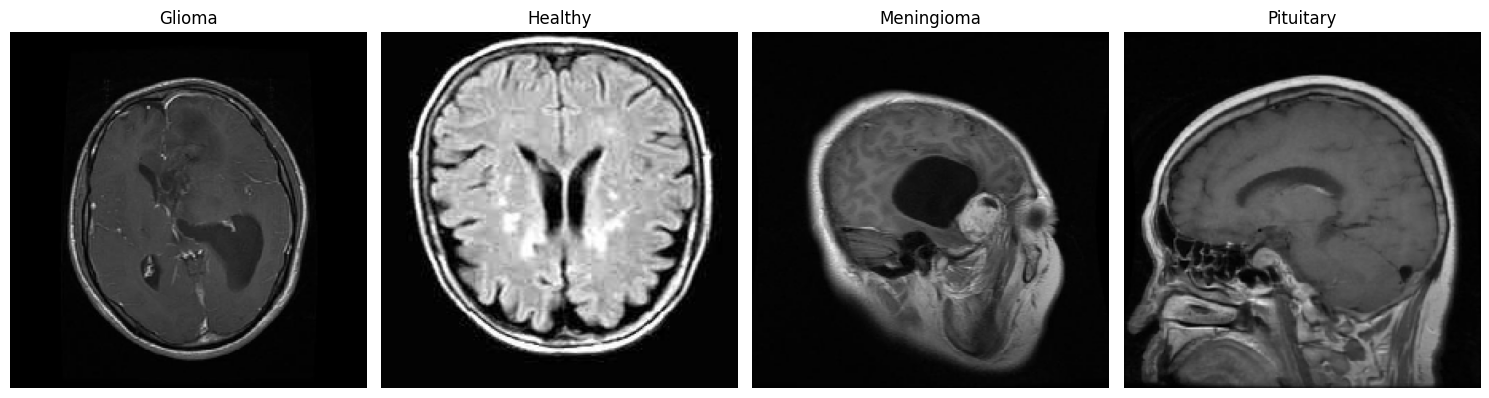

In [82]:
plt.figure(figsize=(15,5))

for i, (_, row) in enumerate(samples_per_class.iterrows()):

    img = tf.keras.utils.load_img(
        row["image_path"],
        target_size=IMG_SIZE
    )

    plt.subplot(1,4,i+1)

    plt.imshow(img)

    plt.title(
        row["label"].capitalize()
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

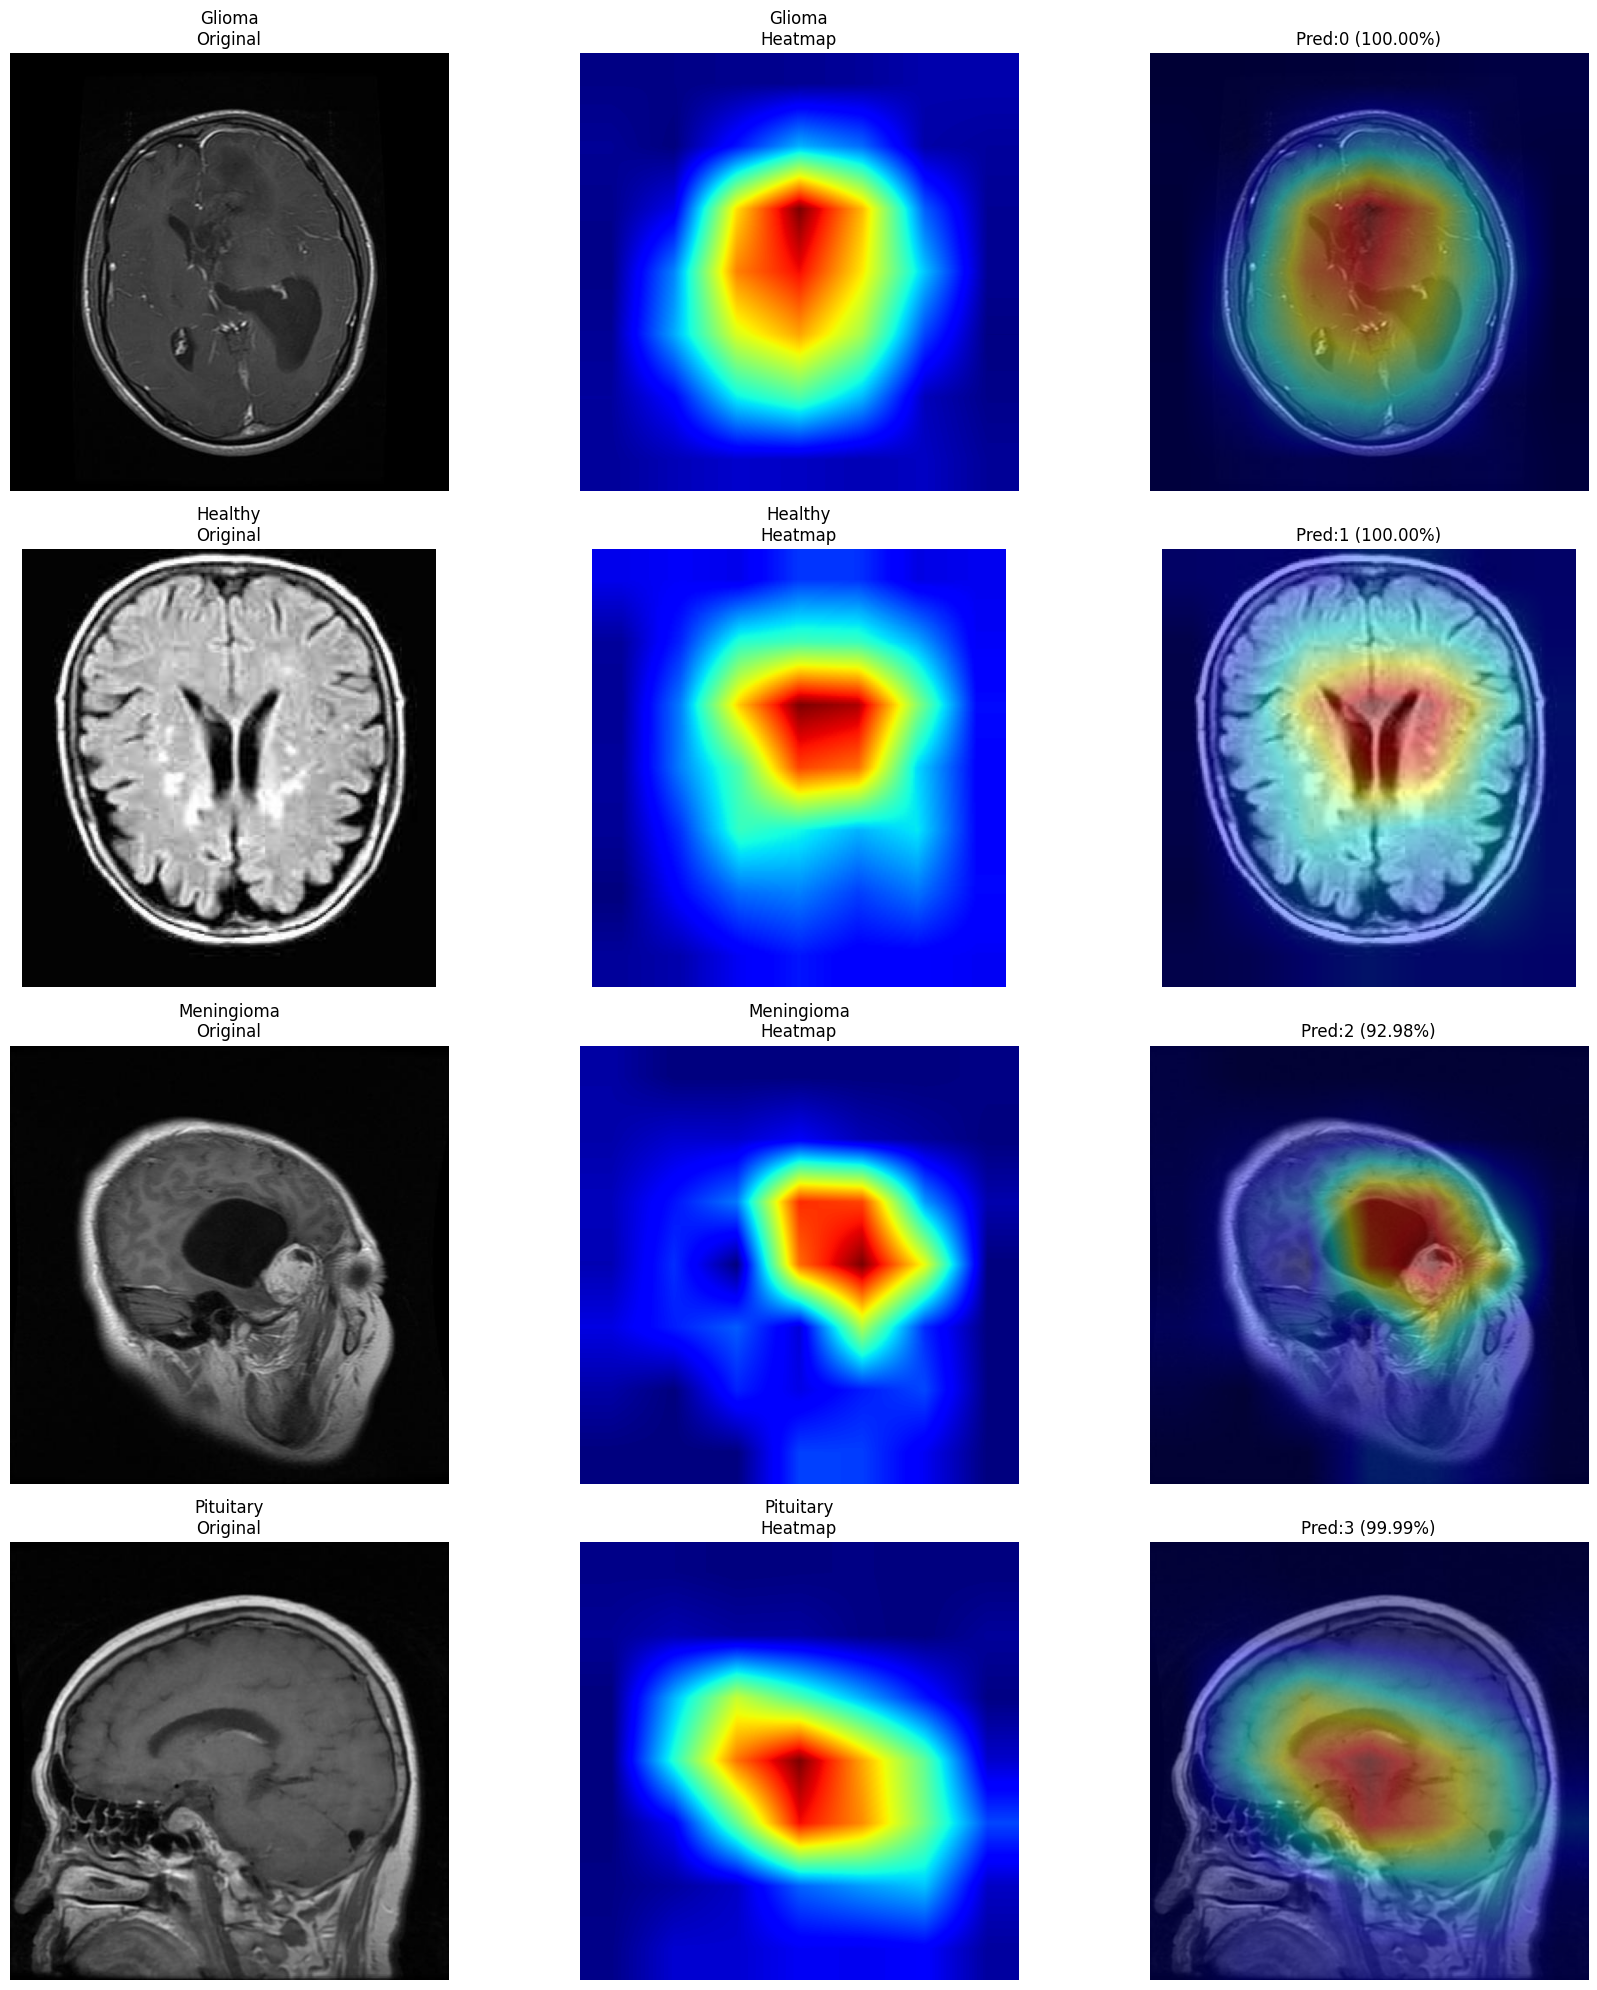

In [85]:
# =========================
# STEP 17: ORIGINAL + HEATMAP + OVERLAY
# =========================

import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(18,20))

for idx, (_, row) in enumerate(samples_per_class.iterrows()):

    sample_path = row["image_path"]

    # Load image
    img = tf.keras.utils.load_img(
        sample_path,
        target_size=IMG_SIZE
    )

    img_array = tf.keras.utils.img_to_array(img)

    img_batch = np.expand_dims(
        img_array,
        axis=0
    )

    img_batch = preprocess_function(
        img_batch
    )

    # Prediksi
    preds = best_model.predict(
        img_batch,
        verbose=0
    )

    pred_class = np.argmax(preds)
    confidence = np.max(preds)

    # GradCAM
    heatmap = make_gradcam_heatmap(
        img_batch,
        best_model
    )

    # Original image
    original = cv2.imread(sample_path)
    original = cv2.cvtColor(
        original,
        cv2.COLOR_BGR2RGB
    )

    # Resize heatmap
    heatmap_resized = cv2.resize(
        heatmap,
        (original.shape[1],
         original.shape[0])
    )

    # Heatmap warna
    heatmap_uint8 = np.uint8(
        255 * heatmap_resized
    )

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    # Overlay
    overlay = cv2.addWeighted(
        original,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    # -------------------
    # ORIGINAL
    # -------------------
    plt.subplot(4,3,idx*3+1)

    plt.imshow(original)

    plt.title(
        f"{row['label'].capitalize()}\nOriginal"
    )

    plt.axis("off")

    # -------------------
    # HEATMAP
    # -------------------
    plt.subplot(4,3,idx*3+2)

    plt.imshow(
        heatmap_resized,
        cmap="jet"
    )

    plt.title(
        f"{row['label'].capitalize()}\nHeatmap"
    )

    plt.axis("off")

    # -------------------
    # OVERLAY
    # -------------------
    plt.subplot(4,3,idx*3+3)

    plt.imshow(overlay)

    plt.title(
        f"Pred:{pred_class} ({confidence:.2%})"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [88]:
densenet_ft.save("densenet_ft.h5")
densenet_non_ft.save("densenet_non_ft.h5")
resnet_ft.save("resnet_ft.h5")
resnet_non_ft.save("resnet_non_ft.h5")
efficientnet_ft.save("efficientnet_ft.h5")
efficientnet_non_ft.save("efficientnet_non_ft.h5")

In [89]:
import zipfile

with zipfile.ZipFile('/kaggle/working/all_models.zip', 'w') as z:
    z.write('/kaggle/working/densenet_ft.h5')
    z.write('/kaggle/working/densenet_non_ft.h5')
    z.write('/kaggle/working/resnet_ft.h5')
    z.write('/kaggle/working/resnet_non_ft.h5')
    z.write('/kaggle/working/efficientnet_ft.h5')
    z.write('/kaggle/working/efficientnet_non_ft.h5')

In [94]:
best_model

<Functional name=ResNet50_Finetuning, built=True>